In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pyarrow
from pathlib import Path
import scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

#Desactivar notacion científica
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_parquet("../data/processed/df_processed.parquet")

In [5]:
df.head(1)

,user_id,user_session,event,product_id,category,price,date,year,month,day,day_of_week,hour,holiday,is_unity_day,is_singles_day,is_black_friday,is_cyber_monday,is_new_year_period,is_orthodox_christmas,is_valentines_day,is_defender_day
date_time,,,,,,,,,,,,,,,,,,,,,
2019-10-01 00:01:46,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,view,5843665,1487580005092295511,9.44,2019-10-01,2019,October,1,Tuesday,0,0,0,0,0,0,0,0,0,0


## Analisis de eventos

#### Comparacion de tipo de evento

In [4]:
df.event.unique()

<ArrowStringArray>
['view', 'cart', 'remove_from_cart', 'purchase']
Length: 4, dtype: str

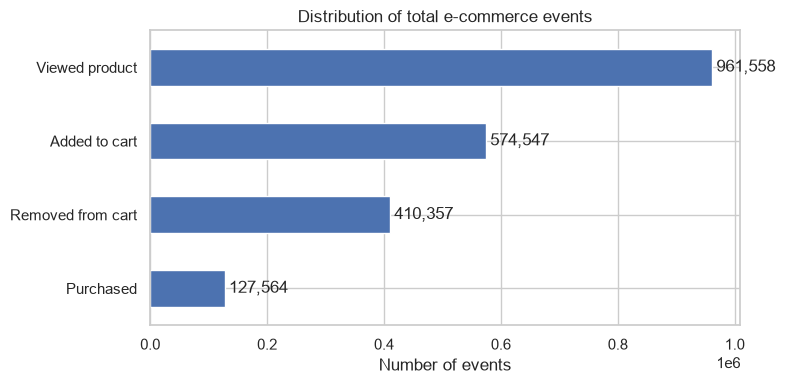

In [250]:
import matplotlib.pyplot as plt

event_labels = {
    "view": "Viewed product",
    "cart": "Added to cart",
    "remove_from_cart": "Removed from cart",
    "purchase": "Purchased"
}
event_counts = (
    df["event"]
    .value_counts()
    .rename(index=event_labels)
    .sort_values()
)
ax = event_counts.plot.barh(figsize=(8, 4))
ax.set(
    title="Distribution of total e-commerce events",
    xlabel="Number of events",
    ylabel=""
)
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

#### Analisis de eventos por hora

In [ ]:
events_by_hour = (
    df.groupby(["hour", "event"])
      .size()
      .unstack(fill_value=0)
      .reindex(range(24), fill_value=0)
      .reset_index()
)

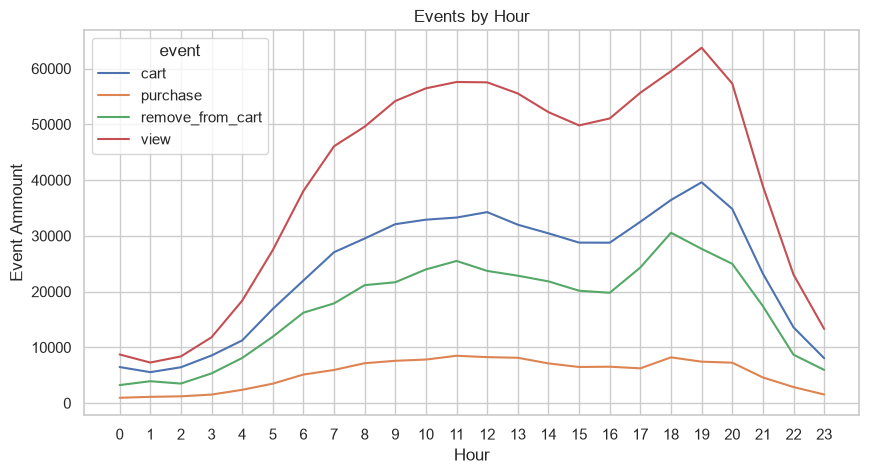

In [ ]:
events_by_hour.set_index("hour").plot(figsize=(10, 5))

plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Event Ammount")
plt.title("Events by Hour")
plt.show()

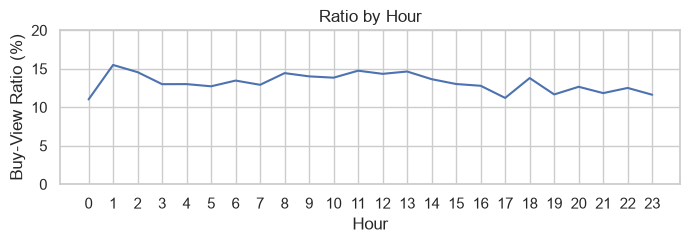

In [ ]:
events_by_hour['buys_views_ratio_pct'] = events_by_hour['purchase'] / events_by_hour['view'] * 100

events_by_hour['buys_views_ratio_pct'].plot(figsize=(8, 2))
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylim(0, 20)
plt.ylabel("Buy-View Ratio (%)")
plt.title("Ratio by Hour")
plt.show()

### Analisis de eventos por sesion

Estadísticos de eventos por sesion

In [134]:
df.event.unique()

<ArrowStringArray>
['view', 'cart', 'remove_from_cart', 'purchase']
Length: 4, dtype: str

In [9]:
session_event = df.groupby(['user_session','event']).product_id.count().unstack().fillna(0)

In [10]:
session_event = session_event[['view','cart','remove_from_cart','purchase']]

In [11]:
session_event.describe().T

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
view,446054.00,2.16,5.29,0.00,1.00,1.00,2.00,1005.00
cart,446054.00,1.29,6.25,0.00,0.00,0.00,0.00,778.00
remove_from_cart,446054.00,0.92,8.93,0.00,0.00,0.00,0.00,2422.00
purchase,446054.00,0.29,2.37,0.00,0.00,0.00,0.00,259.00


<Axes: >

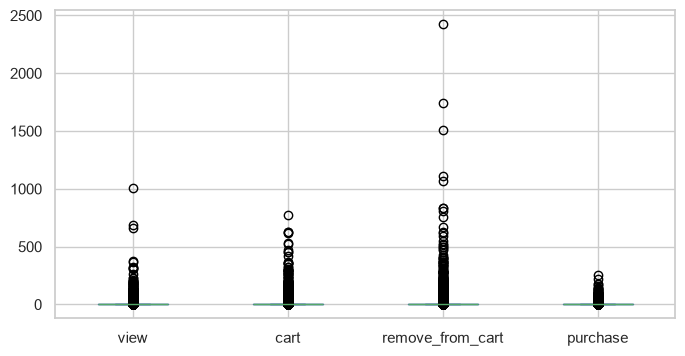

In [12]:
session_event.plot(kind='box',figsize=(8, 4))

Se detectan anomalias importantes: remove from cart es mayor a cart e incluso mayor a view. Se realizara un analisis de outliers para ver que esta sucediendo.

#### Analisis detallado de eventos (outliers)

In [108]:
#variables para visualizar anomalias x evento
df["is_view"] = df["event"].eq("view")
df['is_add_to_cart'] = df["event"].eq("cart")
df['is_remove_from_cart'] = df["event"].eq("remove_from_cart")
df['is_purchase'] = df["event"].eq("purchase")

In [117]:
#dataset de analisis de sesiones

df_events_session = \
    df.reset_index().groupby(['user_session']).agg(
    session_start=("date_time", "min"),
    session_end=("date_time", "max"),
    events=("event", "size"),
    views = ('is_view', 'sum'),
    add_to_cart = ('is_add_to_cart', 'sum'),
    remove_from_cart = ('is_remove_from_cart', 'sum'),
    purchase = ('is_purchase', 'sum')
    ).reset_index().sort_values('events', ascending=False)

#Variables temporales de sesion
df_events_session["duration_minutes"] = (
    df_events_session["session_end"] - df_events_session["session_start"]
).dt.total_seconds() / 60

df_events_session["events_per_minute"] = (
    df_events_session["events"] /
    df_events_session["duration_minutes"].replace(0, pd.NA)
)

In [63]:
df_events_session[df_events_session['events_per_minute'] > 300].sort_values('events', ascending=False).head(20)

,user_session,session_start,session_end,events,views,add_to_cart,remove_from_cart,purchase,duration_minutes,events_per_minute
435280,f9e26dd9-bafb-4dd1-9ffc-57c8b2c1cc86,2020-02-01 08:23:26,2020-02-01 08:23:27,831,0,0,831,0,0.02,49860.00
143787,527e4ab5-a2b5-475d-a8e6-fe7152f6cf2c,2020-02-01 14:54:27,2020-02-01 14:54:29,40,0,17,23,0,0.03,1200.00
293796,a8a374e9-2c53-4209-8b99-4d95b11f3b62,2019-10-09 19:52:08,2019-10-09 19:52:13,27,0,0,27,0,0.08,324.00
320903,b85410fa-b307-2c2c-b8b4-4b35e2432995,2020-02-01 21:12:05,2020-02-01 21:12:06,18,9,0,9,0,0.02,1080.00
255722,92d2dccd-cf20-473b-8b73-d6b167ead3bb,2020-02-16 10:37:32,2020-02-16 10:37:35,17,0,0,17,0,0.05,340.00
347340,c752bf0b-05e7-468d-8567-1d185ccf0f0d,2020-02-03 20:29:55,2020-02-03 20:29:57,15,0,15,0,0,0.03,450.00
242701,8b60955f-f3a0-4b4e-b980-d04587356414,2020-02-03 12:20:54,2020-02-03 12:20:55,13,0,0,13,0,0.02,780.00
331401,be4172f6-8770-450d-8f8d-3765ad3a732c,2020-01-29 16:51:23,2020-01-29 16:51:24,11,1,0,10,0,0.02,660.00
406954,e98d8199-c0d3-48e2-abe4-ef8e39510375,2019-10-09 17:51:56,2019-10-09 17:51:57,7,0,0,7,0,0.02,420.00
374013,d6b9c5fe-a332-4220-8abf-9ff5f866e907,2020-01-17 09:46:55,2020-01-17 09:46:56,6,0,0,6,0,0.02,360.00


In [20]:
df = df.drop(columns=['is_view','is_add_to_cart','is_remove_from_cart','is_purchase'])

- Despues de análisis de eventos con con ventanas temporales **no se puede concluir que haya patrones extremadamente anómalos** debido a que las sesiones con mas eventos por minuto son provocadas por acciones de eliminar la cesta (lo que provoca que grandes cantidades de productos sean eliminados simultaneamente, quedando registrados como eventos de forma individual).

In [43]:
events_by_hour.set_index('hour', inplace=True)
events_by_hour = events_by_hour[['view','cart','remove_from_cart','purchase','buys_views_ratio_pct']]

## Analisis de sesiones y CR

In [ ]:
#Duracion de las sesiones
df_events_session.duration_minutes.describe()

count   446054.00
mean       260.87
std       5211.85
min          0.00
25%          0.00
50%          0.00
75%          1.65
max     217502.07
Name: duration_minutes, dtype: float64

In [ ]:
#Duracion sesiones > 60min
df_events_session.loc[df_events_session["duration_minutes"] > 60, "duration_minutes"].describe( percentiles=[.25, .50, .75, .90, .95, .99])

count    17503.00
mean      6575.83
std      25510.20
min         60.02
25%         88.75
50%        159.37
75%       1060.59
90%       6425.80
95%      32764.22
99%     150287.02
max     217502.07
Name: duration_minutes, dtype: float64

In [111]:
a = df_events_session[df_events_session['duration_minutes'] <= 60].user_session.count()
b = df_events_session[df_events_session['duration_minutes'] > 60].user_session.count()

print(f"sesiones con duracion <= 60 min: {a}")
print(f"sesiones con duracion > 60 min: {b}")
print(f"Porcentaje sesiones > 60 min respecto al total: {(b/(a+b))*100}%")

sesiones con duracion <= 60 min: 428551
sesiones con duracion > 60 min: 17503
Porcentaje sesiones > 60 min respecto al total: 3.923964363059181%


Debido a que la duracion de las sesiones es bastante variable con sesiones de duracion extremadamente largas, se valorará si ignorar las sesiones con duracion > 60min si no representan un alto porcentaje de los ingresoso totales.

In [119]:
#calculamos sales solo de eventos purchase por user_session
session_sales = (
    df.loc[df["event"].eq("purchase")]
      .groupby("user_session", as_index=False)
      .agg(
          revenue=("price", "sum"),
      )
)

In [120]:
#merge de sales en dataset de sesiones
df_events_session = df_events_session.merge(
    session_sales,
    on="user_session",
    how="left",
)

In [122]:
#Rellenar NaN con 0
df_events_session["revenue"] = (
    df_events_session["revenue"].fillna(0)
)

In [149]:
#Categorizar tipo de sesion
df_events_session['duration_group'] = np.where((df_events_session['duration_minutes'] <= 60), 1, 0)

In [215]:
#Suma de renevue total segun tipo de sesion para comprovar relevancia de cada grupo
a = df_events_session.groupby('duration_group')["revenue"].sum().iloc[0]
b = df_events_session.groupby('duration_group')["revenue"].sum().iloc[1]

print(f"revenue total grupo >60min: {a}")
print(f"revenue total grupo <= 60min: {b}")
print(f"Porcentaje de revenue de sesiones >60min sobre el total: {(a/(a+b))*100}%")


revenue total grupo >60min: 131595.28
revenue total grupo <= 60min: 489954.32
Porcentaje de revenue de sesiones >60min sobre el total: 21.172128499479367%


La renevue total de las sesiones >60min es suficientemente relevante como para no ignorarla. Se comprovaran gaps entre eventos en sesiones > 60min.

#### Analisis de gaps en sesiones de usuario >60min para determinar timeouts y reconstruir seasiones anómalas

In [205]:
#creamos dataset temporal para calcular temporalidad de los gaps entre evento dentro de mismo usuario-sesion de forma ordenada
df_session_gaps = (
    df.assign(timestamp=df.index)
      .sort_values(["user_id", "user_session", "timestamp"])
)

In [206]:
#variable de tiempo entre eventos 
df_session_gaps["gap_minutes"] = (
    df_session_gaps
    .groupby("user_session")["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

In [207]:
#Filtro sesiones > 60min
long_session_ids = df_events_session.loc[df_events_session["duration_minutes"] > 60, "user_session"]

#Aplicamos filtro a long_session_gaps
long_session_gaps = df_session_gaps[df_session_gaps["user_session"].isin(long_session_ids)]

In [209]:
long_session_gaps["gap_minutes"].describe(percentiles=[.50, .75, .90, .95, .99])

count   467122.00
mean       246.40
std       4465.62
min          0.00
50%          0.35
75%          1.27
90%          5.12
95%         31.08
99%       1758.60
max     213018.47
Name: gap_minutes, dtype: float64

Esto sigue sin ofrecernos informacion relevante ya que estamos usando todos los gaps dentro de las sesiones más largas, y muchos de esos gaps pueden ser pequeños. Vamos a seguir filtrando para obtener conclusiones.

In [219]:
#Gap maximo de cada sesion sesion larga
max_gap_per_session = (
    long_session_gaps
    .groupby("user_session")["gap_minutes"]
    .max()
)

max_gap_per_session.describe(
    percentiles=[.25, .50, .75, .90, .95, .99]
)

count    17503.00
mean      5538.80
std      22007.21
min          2.77
25%         54.68
50%        111.12
75%        963.55
90%       5286.14
95%      27417.65
99%     130897.29
max     213018.47
Name: gap_minutes, dtype: float64

Ahora si podemos sacar conclusiones más fiables de los gaps de sesiones largas:
- Las 17.503 sesiones largas no forman un grupo homogéneo. Una parte parece perfectamente recuperable como sesión real. Otra parte contiene períodos de inactividad incompatibles con una navegación continua.
- Por ejemplo, el P25 nos dice que al menos un 25% de estas sesiones, aunque duren >60 minutos en total, no tienen ningún gap superior a ~55 minutos.

Va a realizarse un analisis de estos gaps en **ventanas personalizadas** para tomar acciones finales sobre las sesiones

In [ ]:
# gaps de todo el dataset - analisis de ventanas personalizadas
max_gap_all_sessions = (
    df_session_gaps
    .groupby("user_session")["gap_minutes"]
    .max()
)

gap_thresholds = pd.Series({
    "> 30 min": max_gap_all_sessions.gt(30).mean() * 100,
    "> 60 min": max_gap_all_sessions.gt(60).mean() * 100,
    "> 2 h":    max_gap_all_sessions.gt(120).mean() * 100,
    "> 6 h":    max_gap_all_sessions.gt(360).mean() * 100,
    "> 24 h":   max_gap_all_sessions.gt(1440).mean() * 100,
    "> 7 days": max_gap_all_sessions.gt(10080).mean() * 100
})

gap_thresholds.round(2)

> 30 min   4.11
> 60 min   2.85
> 2 h      1.87
> 6 h      1.41
> 24 h     0.75
> 7 days   0.30
dtype: float64

In [ ]:
# gaps de sesiones >60min - analisis de ventanas personalizadas
pd.Series({
    "> 30 min": max_gap_per_session.gt(30).mean() * 100,
    "> 60 min": max_gap_per_session.gt(60).mean() * 100,
    "> 2 h":    max_gap_per_session.gt(120).mean() * 100,
    "> 6 h":    max_gap_per_session.gt(360).mean() * 100,
    "> 24 h":   max_gap_per_session.gt(1440).mean() * 100,
    "> 7 days": max_gap_per_session.gt(10080).mean() * 100
}).round(2)

> 30 min   86.33
> 60 min   72.58
> 2 h      47.67
> 6 h      35.91
> 24 h     19.23
> 7 days    7.54
dtype: float64

#### Conclusiones finales:
- **4,11%** de todas las sesiones tienen algún gap >30 min.
- **2,85%** de todas las sesiones tienen algún gap >60 min.

Debido a que aproximadamente el 97,5% de todo el dataset contiene sesiones con gaps <= 60min, **no es recomendable aplicar cambios sobre todo el dataset**, solo sobre las sesiones largas ya que:
- **86,33%** tienen gaps >30 min
- **72,58%** tienen gaps >60 min

Se ha decidido usar un **threshold de 60min** para dividir sesiones largas ya que **solo afectará al 2,85% de las sesiones totales**.

In [222]:
df_events_session.head()

,user_session,session_start,session_end,events,views,add_to_cart,remove_from_cart,purchase,duration_minutes,events_per_minute,revenue,duration_group
0,9a00249a-68d3-426a-b434-f571adf843dd,2020-02-11 18:14:38,2020-02-11 21:09:35,2793,17,294,2422,60,174.95,15.96,257.49,0
1,6772c164-711e-4b0d-bfc8-a30fcca5a937,2019-10-13 16:51:27,2020-02-28 17:37:25,2478,1005,778,669,26,198765.97,0.01,93.69,0
2,6bb9ee1d-29f0-40b3-acc1-bc248c299d49,2019-11-22 05:39:49,2020-02-26 20:54:32,2402,658,629,1110,5,139154.72,0.02,11.45,0
3,774a7c64-079f-450c-be4a-625aeea3350d,2019-11-04 16:08:48,2019-11-04 18:03:30,2031,4,283,1744,0,114.70,17.71,0.00,0
4,15843513-b7d9-4fa4-8aed-42f39bb99767,2020-01-19 18:38:34,2020-01-19 22:47:46,1704,10,181,1513,0,249.20,6.84,0.00,0


In [232]:
#Nuevo dataset especifico para análisis de sesiones
df_sessions = (
    df.assign(timestamp=df.index)
      .sort_values(["user_id", "user_session", "timestamp"])
      .copy()
)

In [233]:
#Variable para calcular gaps
df_sessions["gap_minutes"] = (
    df_sessions
    .groupby(["user_id", "user_session"])["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

In [234]:
#Variable threshold sesion nueva
df_sessions["new_session"] = df_sessions["gap_minutes"].isna() | df_sessions["gap_minutes"].gt(60)

In [235]:
# Numeramos sesiones de cada usuario
df_sessions["analytical_session_number"] = (
    df_sessions
    .groupby("user_id")["new_session"]
    .cumsum()
)

In [236]:
#Variable para generar nuevas sub-sesiones a partir de las sesiones anómalas
df_sessions["analytical_session"] = (
    df_sessions["user_id"].astype(str)
    + "_"
    + df_sessions["analytical_session_number"].astype(str)
)

In [251]:
#Dataset de sesiones final con variables necesarias para calcular el Conversion Rate
df_sessions["viewed"] = df_sessions["event"].eq("view")
df_sessions["added_to_cart"] = df_sessions["event"].eq("cart")
df_sessions["removed_from_cart"] = df_sessions["event"].eq("remove_from_cart")
df_sessions["purchased"] = df_sessions["event"].eq("purchase")

sessions = (
    df_sessions
    .groupby(
        ["user_id", "analytical_session_number"],
        as_index=False,
        sort=False
    )
    .agg(
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        viewed=("viewed", "max"),
        added_to_cart=("added_to_cart", "max"),
        removed_from_cart=("removed_from_cart", "max"),
        purchased=("purchased", "max")
    )
)

#### Conversion Rate (CR) por sesion

In [ ]:
#Calculamos Conversion Rate
conversion_rate = sessions["purchased"].mean() * 100
conversion_rate

np.float64(3.3569383174676886)

#### Funnel de conversion basado en eventos por sesion

In [252]:
#Funnel de conversion
funnel = (
    sessions[
        ["viewed", "added_to_cart", "purchased"]
    ]
    .sum()
    .rename({
        "viewed": "Viewed product",
        "added_to_cart": "Added to cart",
        "purchased": "Purchased"
    })
)

funnel

Viewed product    436839
Added to cart     101141
Purchased          15615
dtype: int64

In [253]:
funnel_pct = funnel / funnel.iloc[0] * 100
funnel_pct

Viewed product   100.00
Added to cart     23.15
Purchased          3.57
dtype: float64

In [257]:
import plotly.graph_objects as go

funnel = (
    sessions[["viewed", "added_to_cart", "purchased"]]
    .sum()
    .rename({
        "viewed": "Viewed product",
        "added_to_cart": "Added to cart",
        "purchased": "Purchased"
    })
)
percentages = funnel / funnel.iloc[0] * 100

fig = go.Figure(
    go.Funnel(
        y=funnel.index,
        x=funnel.values,
        text=[
            f"{value:,.0f}<br>{pct:.2f}%"
            for value, pct in zip(funnel.values, percentages)
        ],
        textinfo="text"
    )
)

fig.update_layout(
    title="Session-Based Conversion Funnel",
    width=800,
    height=400
)
fig.show()


### Insight 1: CR Global de 3,35% y CR Funnel de 3,57%

1. CR por sesion:

- La **tasa de conversión por sesión es del 3,35%**, lo que significa que aproximadamente **3 de cada 100 sesiones analíticas finalizan con al menos una compra**.

Para calcular este indicador se mantuvieron las sesiones originales como unidad de referencia, pero se corrigieron aquellas que presentaban **periodos de inactividad superiores a 60 minutos**, dividiéndolas en nuevas sesiones analíticas. Esta metodología permite reducir la distorsión provocada por sesiones anormalmente largas, sin eliminar los eventos ni las compras asociadas a ellas. Un CR del **3,35%** indica que existe un volumen considerable de sesiones que no culminan en compra, por lo que resulta relevante analizar las etapas del funnel (`view → cart → purchase`) para identificar los principales puntos de abandono y posibles oportunidades de mejora.

2. Funnel de conversion basado en eventos por sesion:

- En cada sesion analitica establecida **con almenos 1 vista de producto**, hubo un **23,15%** de eventos en los que se añadió almenos un producto al carrito y un **3,57%** de las veces en las que se genero almenos una venta.

La diferencia entre CR Global y CR Funnel se debe a que CR Globasl se calcula como **sesiones con compra/todas las sesiones analiticas** y CR del Funnel se calcula como **sesiones con compra/sesiones con almenos 1 view**.